# Marginal Transforms
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/01_marginal_transforms.ipynb)

This notebook covers the **marginal transforms** used in the RBIG pipeline —
both the theory and all available implementations.

**Contents**

1. [Theory](#theory)
2. [Data](#data)
3. [Step 1 — Marginal Uniformization](#step-1--marginal-uniformization)
4. [Step 2 — Marginal Gaussianization](#step-2--marginal-gaussianization)
5. [All Available Methods](#all-available-methods)
6. [Comparison](#comparison)
7. [Summary](#summary)

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [1]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

---
## Theory

### What is Marginal Gaussianization?

Marginal Gaussianization is a **dimension-wise** (feature-independent)
transform whose Jacobian is a diagonal matrix. It maps each feature of a
$d$-dimensional random variable to a standard Gaussian independently.

### The Pipeline

For each dimension $d$, the transform is a two-step composition:

$$x_d \xrightarrow{F_d} u_d \xrightarrow{\Phi^{-1}} z_d$$

1. **Uniformization** — Estimate the empirical CDF $F_d$ and apply it to
   obtain a uniform variable $u_d \in [0, 1]$:

   $$u_d = F_d(x_d) = \int_{-\infty}^{x_d} p_d(x_d') \, dx_d'$$

2. **Gaussianization** — Apply the inverse Gaussian CDF (probit) to map from
   uniform to Gaussian:

   $$z_d = \Phi^{-1}(u_d)$$

### Why Diagonal Jacobian?

Because each dimension is transformed independently, the Jacobian is diagonal:

$$\log|\det J| = \sum_{d=1}^{D} \log\left|\frac{dz_d}{dx_d}\right|$$

This makes the log-determinant cheap to compute ($O(D)$ instead of $O(D^3)$),
which is critical for density estimation in normalizing flows.

### CDF Estimation Methods

The key design choice is **how to estimate $F_d$**. Different estimators trade
off smoothness, accuracy, and speed:

- **Empirical CDF** (rank-based) — fast, non-parametric, piecewise-constant
- **KDE CDF** — smooth, bandwidth-dependent
- **Quantile transform** — rank-based with interpolation
- **GMM CDF** — parametric mixture, analytic
- **Spline CDF** — smooth monotone interpolation

See the [Uniformization note](../notes/uniformization.md) for the full
mathematical derivation and the
[Marginal Gaussianization note](../notes/marginal_gaussianization.md)
for implementation details.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

from rbig import (
    MarginalUniformize,
    MarginalGaussianize,
    MarginalKDEGaussianize,
    QuantileGaussianizer,
    KDEGaussianizer,
    GMMGaussianizer,
    SplineGaussianizer,
)

plt.style.use("seaborn-v0_8-paper")

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Data

We use a **Gamma(4)** distribution — a skewed, non-Gaussian marginal that
clearly shows the effect of each transform.

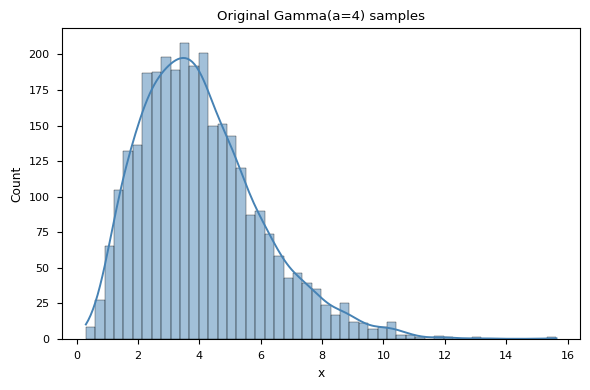

In [3]:
seed = 123
n_samples = 3_000
a = 4  # Gamma shape parameter

data_dist = stats.gamma(a=a)
X = data_dist.rvs(size=(n_samples, 1), random_state=seed)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(X[:, 0], ax=ax, bins=50, kde=True, color="steelblue")
ax.set_title(f"Original Gamma(a={a}) samples")
ax.set_xlabel("x")
plt.tight_layout()
plt.show()

---
## Step 1 — Marginal Uniformization

`MarginalUniformize` uses the empirical CDF (rank-based with Hazen
continuity correction) to map each marginal to Uniform[0, 1].

$$u = \hat{F}_n(x) = \frac{\text{rank}(x) + 0.5}{N}$$

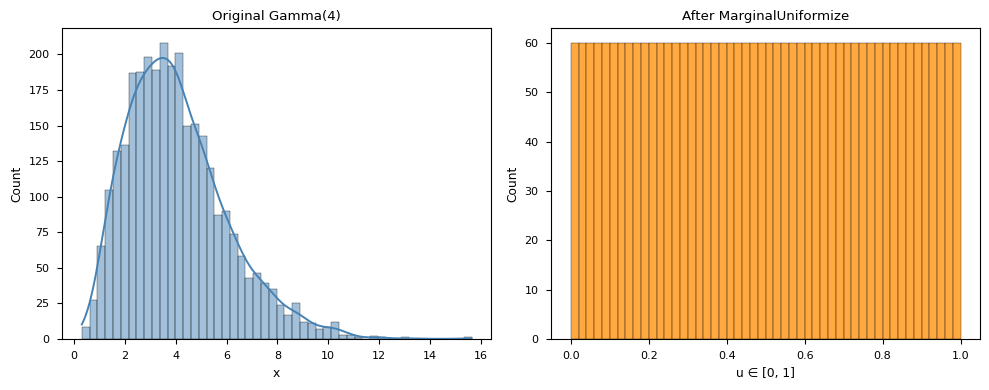

In [4]:
marg_unif = MarginalUniformize(bound_correct=True, eps=1e-6)
marg_unif.fit(X)
Xu = marg_unif.transform(X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X[:, 0], ax=axes[0], bins=50, kde=True, color="steelblue")
axes[0].set_title("Original Gamma(4)")
axes[0].set_xlabel("x")

sns.histplot(Xu[:, 0], ax=axes[1], bins=50, color="darkorange")
axes[1].set_title("After MarginalUniformize")
axes[1].set_xlabel("u ∈ [0, 1]")
plt.tight_layout()
plt.show()

In [5]:
# Round-trip accuracy
X_rt = marg_unif.inverse_transform(Xu)
print(f"Mean |round-trip error|: {np.abs(X - X_rt).mean():.2e}")

Mean |round-trip error|: 2.05e-03


---
## Step 2 — Marginal Gaussianization

`MarginalGaussianize` combines the empirical CDF with the probit transform
$\Phi^{-1}$ in a single step: $z = \Phi^{-1}(\hat{F}_n(x))$.

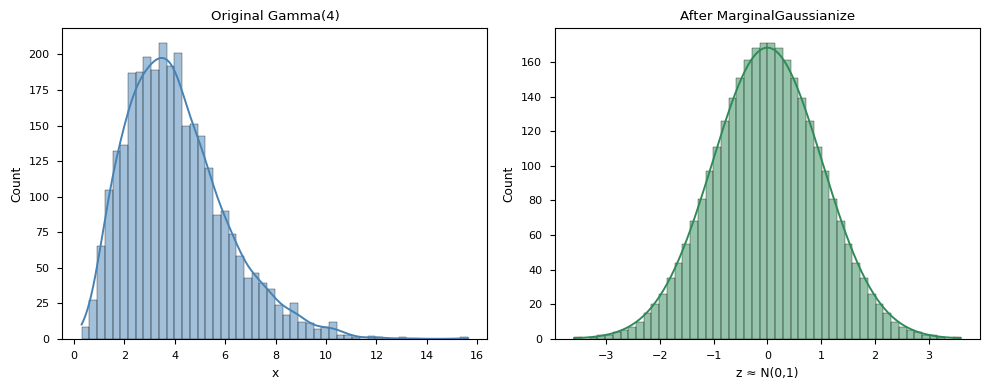

In [6]:
marg_gauss = MarginalGaussianize(bound_correct=True, eps=1e-6)
marg_gauss.fit(X)
Xg = marg_gauss.transform(X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X[:, 0], ax=axes[0], bins=50, kde=True, color="steelblue")
axes[0].set_title("Original Gamma(4)")
axes[0].set_xlabel("x")

sns.histplot(Xg[:, 0], ax=axes[1], bins=50, kde=True, color="seagreen")
axes[1].set_title("After MarginalGaussianize")
axes[1].set_xlabel("z ≈ N(0,1)")
plt.tight_layout()
plt.show()

In [7]:
# Round-trip accuracy
X_rt2 = marg_gauss.inverse_transform(Xg)
print(f"Mean |round-trip error|: {np.abs(X - X_rt2).mean():.2e}")

Mean |round-trip error|: 2.05e-03


In [8]:
# Log-determinant of the Jacobian (needed for density estimation)
log_jac = marg_gauss.log_det_jacobian(X)
print(
    f"log |det J| — min: {log_jac.min():.3f}, max: {log_jac.max():.3f}, "
    f"mean: {log_jac.mean():.3f}"
)

log |det J| — min: -3.029, max: 6.394, mean: -0.014


---
## All Available Methods

Beyond the two core transforms above, `rbig` provides several alternative
marginal Gaussianizers. Each estimates the CDF differently, offering different
tradeoffs in smoothness, speed, and accuracy.

### MarginalKDEGaussianize

Uses a Gaussian KDE to estimate the CDF, then applies probit. Smoother than
the empirical CDF, but slower (inverse uses numerical root-finding).

In [9]:
marg_kde = MarginalKDEGaussianize(bw_method="scott", eps=1e-6)
marg_kde.fit(X)
Xg_kde = marg_kde.transform(X)

### QuantileGaussianizer

Wraps sklearn's `QuantileTransformer` with `output_distribution='normal'`.
Rank-based with piecewise-linear interpolation between quantile nodes.

In [10]:
quant_gauss = QuantileGaussianizer(n_quantiles=1000, random_state=0)
quant_gauss.fit(X)
Xg_quant = quant_gauss.transform(X)

### KDEGaussianizer

Similar to `MarginalKDEGaussianize` but implements the `Bijector` interface
with an analytic `get_log_det_jacobian` using the KDE density directly.

In [11]:
kde_gauss = KDEGaussianizer(bw_method="scott", eps=1e-6)
kde_gauss.fit(X)
Xg_kde2 = kde_gauss.transform(X)

### GMMGaussianizer

Fits a univariate Gaussian Mixture Model per feature and uses the analytic
GMM CDF: $F_\text{GMM}(x) = \sum_k w_k \Phi\!\left(\frac{x - \mu_k}{\sigma_k}\right)$.

In [12]:
gmm_gauss = GMMGaussianizer(n_components=5, random_state=0)
gmm_gauss.fit(X)
Xg_gmm = gmm_gauss.transform(X)

### SplineGaussianizer

Fits a monotone PCHIP (Piecewise Cubic Hermite Interpolating Polynomial)
spline from data quantiles to Gaussian quantiles. Smooth, fast, and
analytically differentiable.

In [13]:
spline_gauss = SplineGaussianizer(n_quantiles=200, eps=1e-6)
spline_gauss.fit(X)
Xg_spline = spline_gauss.transform(X)

---
## Comparison

### Visual comparison of all outputs

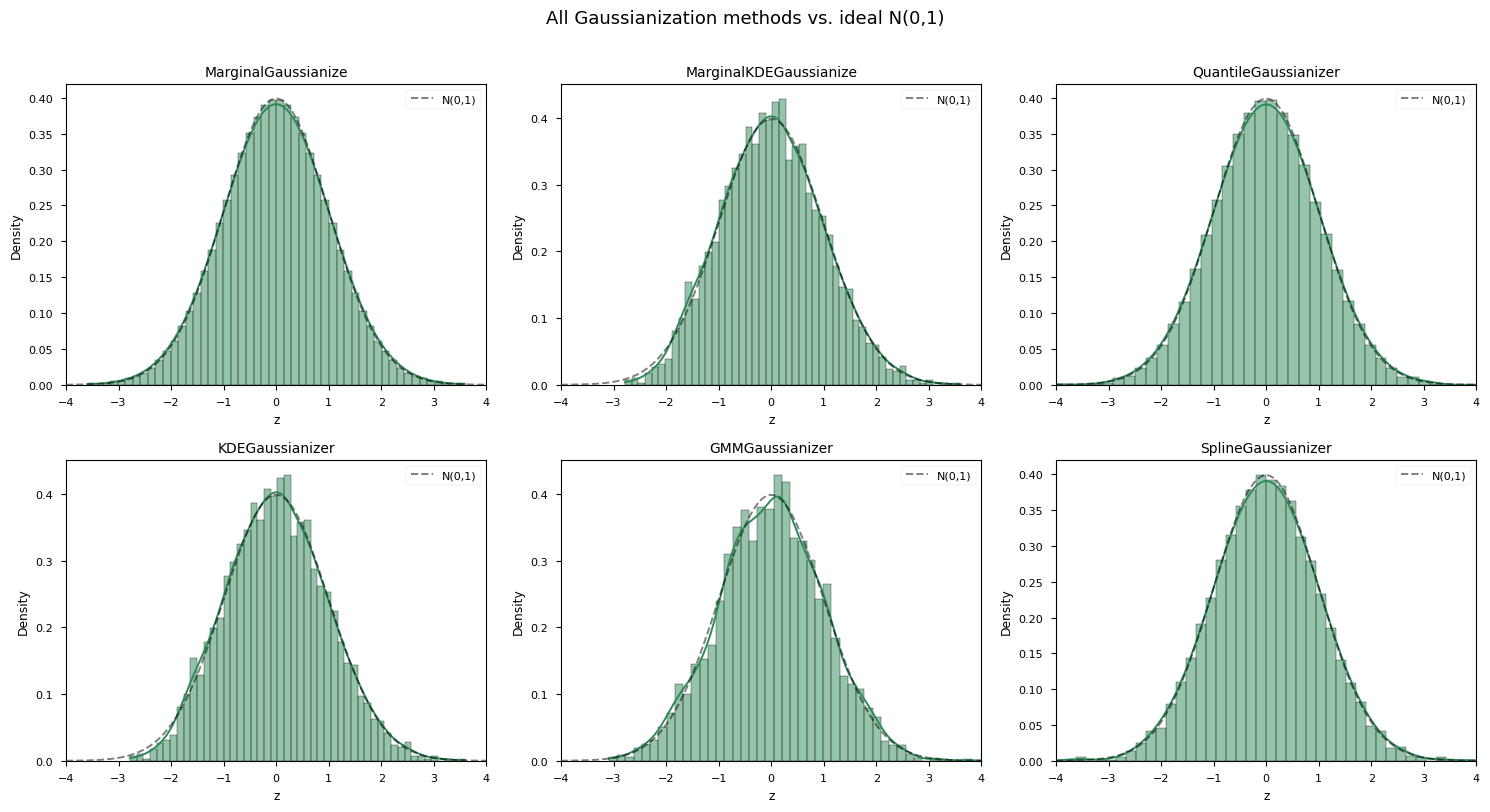

In [14]:
results = {
    "MarginalGaussianize": Xg,
    "MarginalKDEGaussianize": Xg_kde,
    "QuantileGaussianizer": Xg_quant,
    "KDEGaussianizer": Xg_kde2,
    "GMMGaussianizer": Xg_gmm,
    "SplineGaussianizer": Xg_spline,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, Zg) in zip(axes.ravel(), results.items()):
    sns.histplot(Zg[:, 0], ax=ax, bins=50, kde=True, color="seagreen", stat="density")
    # overlay ideal N(0,1)
    xx = np.linspace(-4, 4, 200)
    ax.plot(xx, stats.norm.pdf(xx), "k--", alpha=0.5, label="N(0,1)")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("z")
    ax.set_xlim(-4, 4)
    ax.legend(fontsize=8)

plt.suptitle("All Gaussianization methods vs. ideal N(0,1)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Round-trip accuracy

In [15]:
models = {
    "MarginalGaussianize": marg_gauss,
    "MarginalKDEGaussianize": marg_kde,
    "QuantileGaussianizer": quant_gauss,
    "KDEGaussianizer": kde_gauss,
    "GMMGaussianizer": gmm_gauss,
    "SplineGaussianizer": spline_gauss,
}

print(f"{'Method':<25s} {'Mean |error|':>12s}")
print("-" * 40)
for name, model in models.items():
    Zg = model.transform(X)
    if name == "MarginalKDEGaussianize":
        # KDE inverse is slow — use a subset
        X_sub = X[:500]
        Zg_sub = model.transform(X_sub)
        X_rec = model.inverse_transform(Zg_sub)
        err = np.abs(X_sub - X_rec).mean()
        print(f"{name:<25s} {err:>12.2e}  (n=500)")
    else:
        X_rec = model.inverse_transform(Zg)
        err = np.abs(X - X_rec).mean()
        print(f"{name:<25s} {err:>12.2e}")

Method                    Mean |error|
----------------------------------------
MarginalGaussianize           2.05e-03


MarginalKDEGaussianize        4.45e-14  (n=500)
QuantileGaussianizer          4.41e-16


KDEGaussianizer               3.92e-14


GMMGaussianizer               2.60e-04
SplineGaussianizer            2.27e-04


### Log-determinant Jacobian

In [16]:
print(f"{'Method':<25s} {'mean log|det J|':>16s}")
print("-" * 44)
for name, model in models.items():
    for method in ("log_det_jacobian", "get_log_det_jacobian"):
        fn = getattr(model, method, None)
        if fn is not None:
            try:
                ldj = fn(X)
                print(f"{name:<25s} {ldj.mean():>16.4f}")
                break
            except (NotImplementedError, AttributeError):
                continue
    else:
        print(f"{name:<25s} {'N/A':>16s}")

Method                     mean log|det J|
--------------------------------------------
MarginalGaussianize                -0.0141
MarginalKDEGaussianize                 N/A
QuantileGaussianizer               -0.8976


KDEGaussianizer                    -0.6351
GMMGaussianizer                    -0.6035
SplineGaussianizer                 -0.5580


---
## Summary

| Class | CDF Method | Output | Inverse | log\|det J\| | Best for |
|-------|-----------|--------|---------|-------------|----------|
| `MarginalUniformize` | Empirical (rank) | Uniform | Fast (interp) | N/A | Pre-processing / uniformization step |
| `MarginalGaussianize` | Empirical + probit | Gaussian | Fast (interp) | Yes | Default in `RBIGLayer` |
| `MarginalKDEGaussianize` | KDE + probit | Gaussian | Slow (root-find) | Yes | Smooth CDF, small data |
| `QuantileGaussianizer` | Quantile (sklearn) | Gaussian | Fast (interp) | Yes (finite diff) | Large data, sklearn integration |
| `KDEGaussianizer` | KDE + probit | Gaussian | Slow (root-find) | Yes (analytic) | When analytic Jacobian needed |
| `GMMGaussianizer` | GMM CDF + probit | Gaussian | Slow (root-find) | Yes (analytic) | Multimodal marginals |
| `SplineGaussianizer` | PCHIP spline | Gaussian | Fast (spline) | Yes (analytic) | Smooth + fast + accurate |

All transforms follow the scikit-learn API: `.fit(X)`, `.transform(X)`,
`.inverse_transform(Z)`.